<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/CNN%2CApriori%2CEvaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Phase 1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Step1: Load the dataset
# Replace 'your_dataset.csv' with the actual path to your dataset
df = pd.read_csv("//content//Food_Delivery_Time_Prediction (2).csv")

In [ ]:
# Step 2: Extract Latitude and Longitude
def extract_lat_lon(coord_str):
    coord = coord_str.strip("()").split(",")
    return float(coord[0]), float(coord[1])

df[['Cust_Lat', 'Cust_Lon']] = df['Customer_Location'].apply(lambda x: pd.Series(extract_lat_lon(x)))
df[['Rest_Lat', 'Rest_Lon']] = df['Restaurant_Location'].apply(lambda x: pd.Series(extract_lat_lon(x)))

# Step 3: Calculate Haversine Distance
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon2
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

df['Geo_Distance'] = df.apply(lambda row: haversine(row['Cust_Lat'], row['Cust_Lon'],
                                                    row['Rest_Lat'], row['Rest_Lon']), axis=1)

# Step 4: Create Rush Hour Feature
rush_hours = ['Morning', 'Evening']
df['Rush_Hour'] = df['Order_Time'].apply(lambda x: 1 if x in rush_hours else 0)

# Step 5: Create Binary Target Column ('Fast' if <= 45 minutes else 'Delayed')
df['Delivery_Status'] = df['Delivery_Time'].apply(lambda x: 'Delayed' if x > 45 else 'Fast')

# Step 6: One-Hot Encode Categorical Features
cat_cols = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Step 7: Normalize Numerical Features
scaler = StandardScaler()
num_cols = ['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating',
            'Customer_Rating', 'Order_Cost', 'Tip_Amount', 'Geo_Distance']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Step 8: Clean Final Dataset
df_encoded.drop(columns=['Order_ID', 'Customer_Location', 'Restaurant_Location',
                         'Cust_Lat', 'Cust_Lon', 'Rest_Lat', 'Rest_Lon', 'Delivery_Time'], inplace=True)

# Step 9: Encode Target Column
df_encoded['Delivery_Status'] = df_encoded['Delivery_Status'].map({'Fast': 0, 'Delayed': 1})

# Optional: Preview Final Dataset
df_encoded.head()

,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount,Geo_Distance,Rush_Hour,Delivery_Status,Weather_Conditions_Rainy,...,Weather_Conditions_Sunny,Traffic_Conditions_Low,Traffic_Conditions_Medium,Order_Priority_Low,Order_Priority_Medium,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car
0,-1.454738,-0.456512,0.515500,-0.987317,0.501852,1.192403,0.500548,0,0,True,...,False,False,True,False,True,False,False,False,False,True
1,1.439192,1.004325,1.085900,0.738511,-1.634294,-0.600810,-0.968883,0,1,False,...,False,False,True,True,False,False,False,True,False,True
2,-0.666417,1.369535,-0.625302,-0.412041,1.092646,0.599332,0.174766,0,1,False,...,False,False,True,False,False,False,False,True,True,False
3,0.335835,-1.186930,-0.767902,0.019416,-0.923323,1.113532,0.001038,1,1,False,...,False,True,False,False,True,True,False,False,True,False
4,-0.700119,0.273907,-0.340101,-1.274955,-0.779755,-1.511757,-1.311604,0,0,True,...,False,False,False,True,False,False,False,True,True,False


#Phase 2

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Features and Target
X = df_encoded.drop('Delivery_Status', axis=1).values
y = df_encoded['Delivery_Status'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape for 1D CNN: (samples, features, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [ ]:
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 18, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 7, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,753 (73.25 KB)

 Trainable params: 18,753 (73.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Reshape input for CNN (ensure float32 type)
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)).astype('float32')
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1)).astype('float32')

# Convert y to float32 as well
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# Fit the CNN model
history = model.fit(X_train_cnn, y_train,
                    epochs=30,
                    batch_size=16,
                    validation_data=(X_test_cnn, y_test))


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7177 - loss: 0.6142 - val_accuracy: 0.7500 - val_loss: 0.5844
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7531 - loss: 0.5623 - val_accuracy: 0.7500 - val_loss: 0.5804
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8090 - loss: 0.4803 - val_accuracy: 0.7500 - val_loss: 0.5739
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7378 - loss: 0.5782 - val_accuracy: 0.7500 - val_loss: 0.5652
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8180 - loss: 0.4821 - val_accuracy: 0.7500 - val_loss: 0.5592
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7571 - loss: 0.5248 - val_accuracy: 0.7500 - val_loss: 0.5561
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7454 - loss: 0.5479 - val_accuracy: 0.7500 - val_loss: 0.5538
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7713 - loss: 0.5004 - val_accuracy: 0.7500 - v

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step
📋 Classification Report:
              precision    recall  f1-score   support

         0.0       0.25      0.20      0.22        10
         1.0       0.75      0.80      0.77        30

    accuracy                           0.65        40
   macro avg       0.50      0.50      0.50        40
weighted avg       0.62      0.65      0.64        40



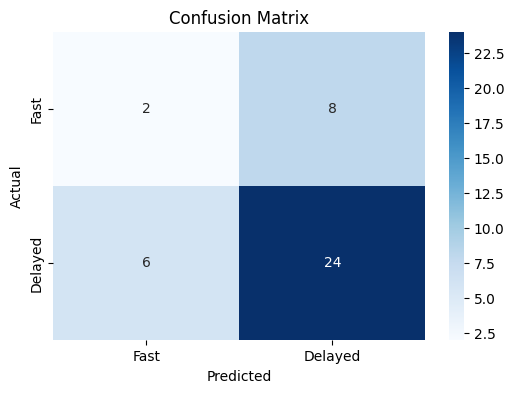

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(X_test_cnn)

# Convert to binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print("📋 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fast', 'Delayed'], yticklabels=['Fast', 'Delayed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


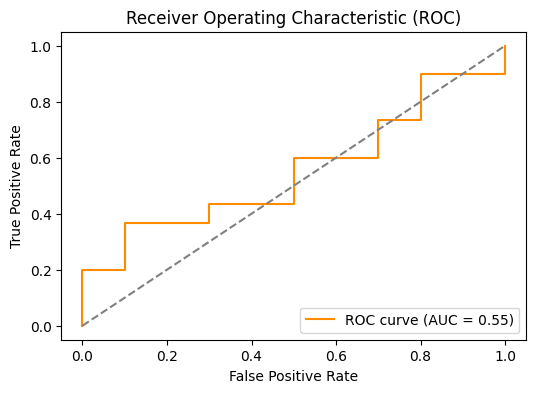

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


📊 Logistic Regression Performance:
              precision    recall  f1-score   support

         0.0       0.50      0.10      0.17        10
         1.0       0.76      0.97      0.85        30

    accuracy                           0.75        40
   macro avg       0.63      0.53      0.51        40
weighted avg       0.70      0.75      0.68        40



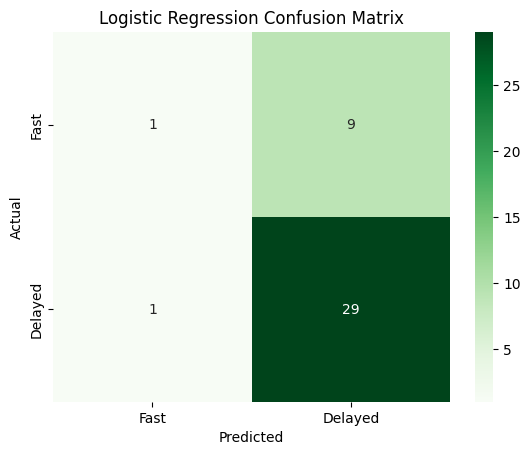

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression on original tabular data
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predict
log_pred = log_model.predict(X_test)

# Evaluate
print("📊 Logistic Regression Performance:")
print(classification_report(y_test, log_pred))

# Confusion Matrix
log_conf_matrix = confusion_matrix(y_test, log_pred)
sns.heatmap(log_conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['Fast', 'Delayed'], yticklabels=['Fast', 'Delayed'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import tensorflow as tf
import numpy as np

# Set number of folds
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

fold = 1
acc_per_fold = []

for train_index, val_index in kf.split(X):
    print(f"\n🔁 Fold {fold}")

    # Split the data
    X_train_fold, X_val_fold = X[train_index], X[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    # Reshape and cast
    X_train_fold = X_train_fold.reshape(X_train_fold.shape[0], X_train_fold.shape[1], 1).astype('float32')
    X_val_fold = X_val_fold.reshape(X_val_fold.shape[0], X_val_fold.shape[1], 1).astype('float32')
    y_train_fold = y_train_fold.astype('float32')
    y_val_fold = y_val_fold.astype('float32')

    # Build CNN model (fresh for each fold)
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv1D(32, 3, activation='relu', input_shape=(X.shape[1], 1)),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train
    model.fit(X_train_fold, y_train_fold, epochs=20, batch_size=16, verbose=0)

    # Evaluate
    val_pred_prob = model.predict(X_val_fold)
    val_pred = (val_pred_prob > 0.5).astype(int)

    acc = accuracy_score(y_val_fold, val_pred)
    acc_per_fold.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

    fold += 1

# Overall Performance
print("\n📊 Cross-Validation Accuracy per Fold:", acc_per_fold)
print(f"📈 Average Accuracy: {np.mean(acc_per_fold):.4f}")



🔁 Fold 1
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Fold 1 Accuracy: 0.7500

🔁 Fold 2


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Accuracy: 0.7250

🔁 Fold 3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Fold 3 Accuracy: 0.7000

🔁 Fold 4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 461ms/step
Fold 4 Accuracy: 0.7000

🔁 Fold 5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Fold 5 Accuracy: 0.5750

📊 Cross-Validation Accuracy per Fold: [0.75, 0.725, 0.7, 0.7, 0.575]
📈 Average Accuracy: 0.6900


In [ ]:
def build_cnn_model(filters=32, kernel_size=3, dropout_rate=0.3):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv1D(filters, kernel_size, activation='relu', input_shape=(X.shape[1], 1)),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(filters*2, kernel_size, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
model = build_cnn_model(filters=64, kernel_size=5, dropout_rate=0.5)
model.fit(X_train_cnn, y_train, epochs=30, batch_size=32, validation_data=(X_test_cnn, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.5658 - loss: 0.6607 - val_accuracy: 0.7500 - val_loss: 0.5761
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7738 - loss: 0.5600 - val_accuracy: 0.7500 - val_loss: 0.5751
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7482 - loss: 0.5670 - val_accuracy: 0.7500 - val_loss: 0.5694
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7660 - loss: 0.5617 - val_accuracy: 0.7500 - val_loss: 0.5582
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7525 - loss: 0.5551 - val_accuracy: 0.7500 - val_loss: 0.5553
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7877 - loss: 0.5208 - val_accuracy: 0.7500 - val_loss: 0.5490
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7295 - loss: 0.5535 - val_accuracy: 0.7500 - val_loss: 0.5436
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7855 - loss: 0.5126 - val_accuracy: 0.7500 - val_loss: 0.5399
